# Bitmapper playground

Iterate on the retro bitmap filter visually. All the actual logic lives in the `bitmapper` package (not in this notebook) so it stays unit-testable.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from bitmapper import BitmapFilterConfig, apply_bitmap_filter, list_palettes

print("Available fixed palettes:", list_palettes())

Matplotlib is building the font cache; this may take a moment.


Available fixed palettes: ['cga', 'ega', 'gameboy', 'vga256']


## Load a source image

Point `IMAGE_PATH` at a real photo if you have one. If it's missing, a synthetic gradient/checker test image is generated instead.

sample.jpg not found, generating a synthetic test image instead.


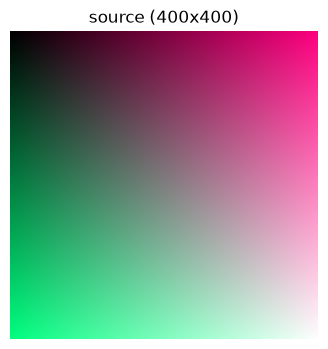

In [2]:
IMAGE_PATH = Path("sample.jpg")

if IMAGE_PATH.exists():
    source_image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
else:
    print(f"{IMAGE_PATH} not found, generating a synthetic test image instead.")
    size = 400
    yy, xx = np.mgrid[0:size, 0:size]
    r = (xx / size * 255).astype(np.uint8)
    g = (yy / size * 255).astype(np.uint8)
    b = (((xx + yy) / (2 * size)) * 255).astype(np.uint8)
    source_image = np.stack([r, g, b], axis=-1)

plt.figure(figsize=(4, 4))
plt.imshow(source_image)
plt.title(f"source ({source_image.shape[1]}x{source_image.shape[0]})")
plt.axis("off")
plt.show()

## Try a single configuration

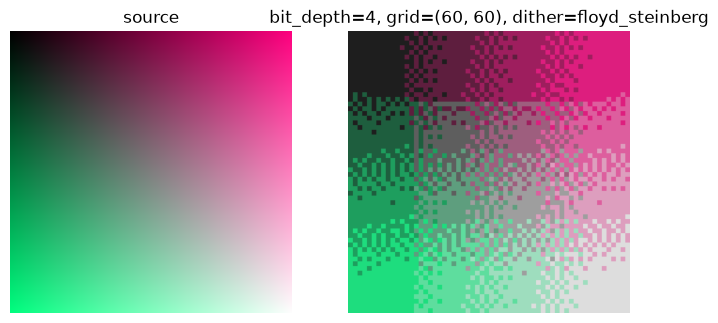

colors used: 16


In [3]:
config = BitmapFilterConfig(
    output_size=(600, 600),
    grid_size=(60, 60),
    bit_depth=4,
    block_sampling="average",
    palette_mode="auto",
    palette_algorithm="median_cut",
    dither="floyd_steinberg",
)

result = apply_bitmap_filter(source_image, config)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(source_image)
axes[0].set_title("source")
axes[0].axis("off")
axes[1].imshow(result.output)
axes[1].set_title(f"bit_depth={config.bit_depth}, grid={config.grid_size}, dither={config.dither}")
axes[1].axis("off")
plt.show()

print("colors used:", len(set(map(tuple, result.output.reshape(-1, 3)))))

## Compare bit depths side by side

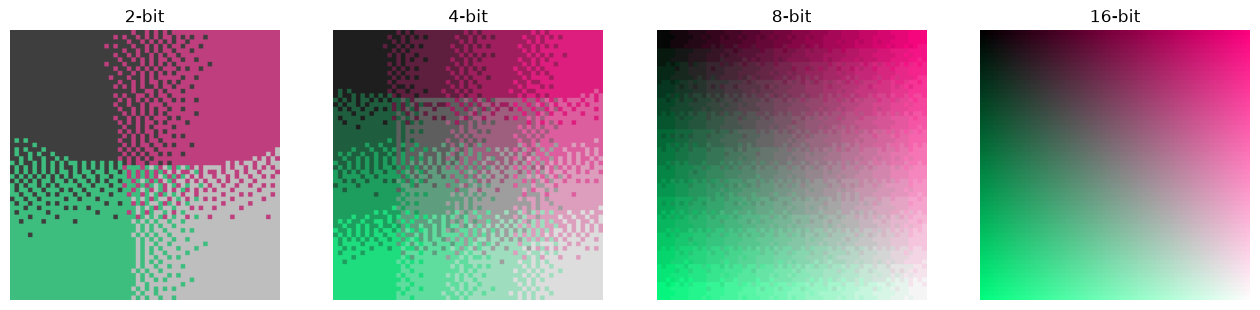

In [4]:
bit_depths = [2, 4, 8, 16]

fig, axes = plt.subplots(1, len(bit_depths), figsize=(4 * len(bit_depths), 4))
for ax, depth in zip(axes, bit_depths):
    cfg = BitmapFilterConfig(output_size=(600, 600), grid_size=(60, 60), bit_depth=depth, dither="floyd_steinberg")
    res = apply_bitmap_filter(source_image, cfg)
    ax.imshow(res.output)
    ax.set_title(f"{depth}-bit")
    ax.axis("off")
plt.show()

## Compare dithering methods

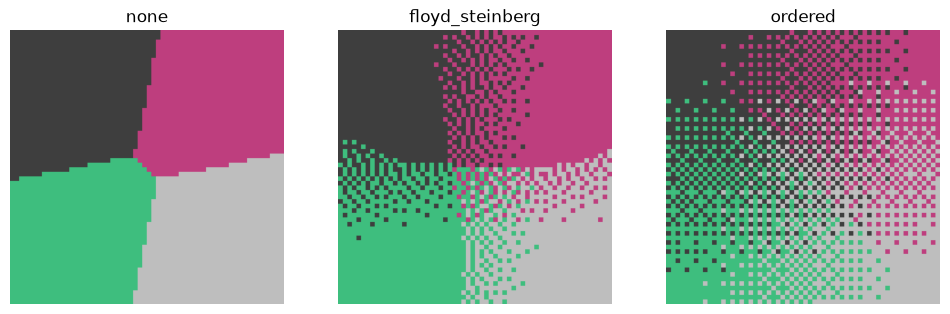

In [5]:
dither_methods = ["none", "floyd_steinberg", "ordered"]

fig, axes = plt.subplots(1, len(dither_methods), figsize=(4 * len(dither_methods), 4))
for ax, method in zip(axes, dither_methods):
    cfg = BitmapFilterConfig(output_size=(600, 600), grid_size=(60, 60), bit_depth=2, dither=method)
    res = apply_bitmap_filter(source_image, cfg)
    ax.imshow(res.output)
    ax.set_title(method)
    ax.axis("off")
plt.show()

## Fixed retro palettes

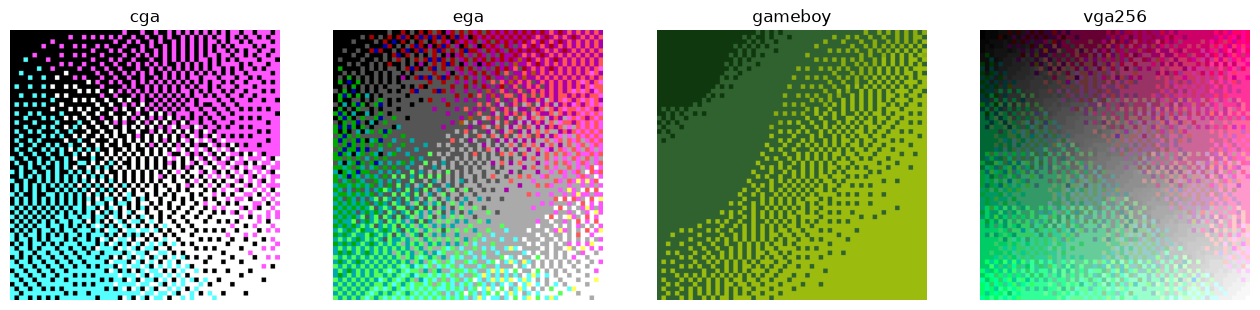

In [6]:
palette_names = list_palettes()

fig, axes = plt.subplots(1, len(palette_names), figsize=(4 * len(palette_names), 4))
for ax, name in zip(axes, palette_names):
    cfg = BitmapFilterConfig(
        output_size=(600, 600), grid_size=(60, 60), bit_depth=8,
        palette_mode="fixed", fixed_palette=name, dither="floyd_steinberg",
    )
    res = apply_bitmap_filter(source_image, cfg)
    ax.imshow(res.output)
    ax.set_title(name)
    ax.axis("off")
plt.show()

## Grid resolution / block size

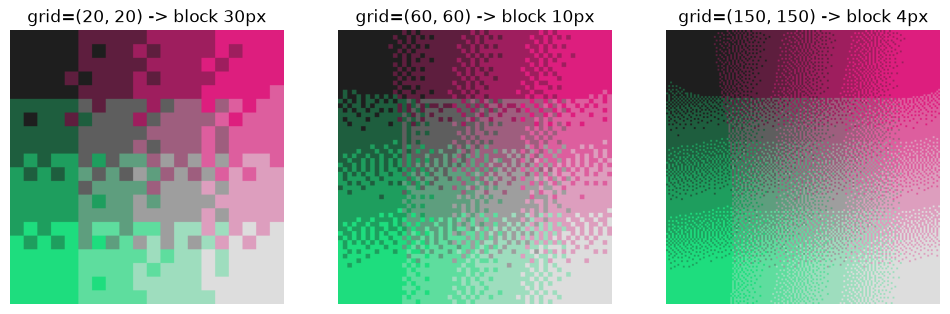

In [7]:
grid_sizes = [(20, 20), (60, 60), (150, 150)]

fig, axes = plt.subplots(1, len(grid_sizes), figsize=(4 * len(grid_sizes), 4))
for ax, gsize in zip(axes, grid_sizes):
    cfg = BitmapFilterConfig(output_size=(600, 600), grid_size=gsize, bit_depth=4, dither="floyd_steinberg")
    res = apply_bitmap_filter(source_image, cfg)
    ax.imshow(res.output)
    ax.set_title(f"grid={gsize} -> block {600 // gsize[0]}px")
    ax.axis("off")
plt.show()